# MATH 5010 — Computer Lab 12–13: Point Estimation

## Full solutions included

This lab supports **Sections 12 and 13: Point Estimation** in MATH 5010 Foundations of Statistical Theory & Probability.

The main ideas are:

1. Understand an estimator as a random variable.
2. Compute and simulate **bias**, **variance**, and **mean squared error**.
3. Derive and implement **method of moments estimators**.
4. Derive and implement **maximum likelihood estimators**.
5. Use conjugate Bayesian estimators for Poisson and Exponential models.
6. Check consistency numerically.
7. Compute Fisher information and compare estimator variance with the **Cramér--Rao lower bound**.

Throughout the lab, formulas are written using the same parameterizations used in class:

- If $X \sim \operatorname{Poisson}(\lambda)$, then $E[X]=\lambda$ and $\operatorname{Var}(X)=\lambda$.
- If $Y \sim \operatorname{Exp}(\theta)$ with density $f(y|\theta)=\frac{1}{\theta}e^{-y/\theta}$, then $\theta$ is the **mean/scale** parameter, so $E[Y]=\theta$ and $\operatorname{Var}(Y)=\theta^2$.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, log, exp
import scipy.stats as st
from scipy.optimize import minimize_scalar

rng = np.random.default_rng(5010)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

# Small helper functions

def summarize_estimates(estimates, true_value):
    # Return empirical bias, variance, and MSE for many simulated estimates.
    estimates = np.asarray(estimates)
    bias = estimates.mean() - true_value
    var = estimates.var(ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    return pd.Series({
        "mean of estimates": estimates.mean(),
        "true value": true_value,
        "bias": bias,
        "variance": var,
        "MSE": mse,
    })

def show_table(df, digits=4):
    return df.round(digits)

## Part 1. Estimators as random variables

Suppose $X_1,\ldots,X_n$ are independent observations from a model indexed by a parameter $\theta$.

An **estimator** $\hat\theta = T(X_1,\ldots,X_n)$ is a statistic used to estimate $\theta$.

Important performance measures:

$$
\operatorname{Bias}(\hat\theta)=E[\hat\theta]-\theta,
$$

$$
\operatorname{Var}(\hat\theta)=E\left[(\hat\theta-E[\hat\theta])^2\right],
$$

$$
\operatorname{MSE}(\hat\theta)=E\left[(\hat\theta-\theta)^2\right]
=\operatorname{Var}(\hat\theta)+\operatorname{Bias}(\hat\theta)^2.
$$

### Exercise 1

Let $X_1,\ldots,X_n \overset{iid}{\sim} N(\mu,\sigma^2)$ with $\sigma$ known. Consider two estimators of $\mu$:

$$
\hat\mu_1=\bar X,
\qquad
\hat\mu_2=X_1.
$$

1. Find $E[\hat\mu_1]$, $\operatorname{Var}(\hat\mu_1)$, and $\operatorname{MSE}(\hat\mu_1)$.
2. Find $E[\hat\mu_2]$, $\operatorname{Var}(\hat\mu_2)$, and $\operatorname{MSE}(\hat\mu_2)$.
3. Simulate both estimators and compare.

### Solution 1

Because $E[\bar X]=\mu$ and $\operatorname{Var}(\bar X)=\sigma^2/n$,

$$
\operatorname{Bias}(\bar X)=0,
\qquad
\operatorname{MSE}(\bar X)=\frac{\sigma^2}{n}.
$$

Because $E[X_1]=\mu$ and $\operatorname{Var}(X_1)=\sigma^2$,

$$
\operatorname{Bias}(X_1)=0,
\qquad
\operatorname{MSE}(X_1)=\sigma^2.
$$

Both estimators are unbiased, but $\bar X$ is much more stable when $n$ is large.

In [2]:
# Simulation for Exercise 1
mu = 10
sigma = 2
n = 25
B = 20_000

samples = rng.normal(loc=mu, scale=sigma, size=(B, n))
mu_hat_1 = samples.mean(axis=1)
mu_hat_2 = samples[:, 0]

comparison = pd.DataFrame({
    "sample mean": summarize_estimates(mu_hat_1, mu),
    "first observation": summarize_estimates(mu_hat_2, mu),
}).T

show_table(comparison)

,mean of estimates,true value,bias,variance,MSE
sample mean,10.0052,10.0,0.0052,0.1608,0.1608
first observation,10.0175,10.0,0.0175,3.9930,3.9931


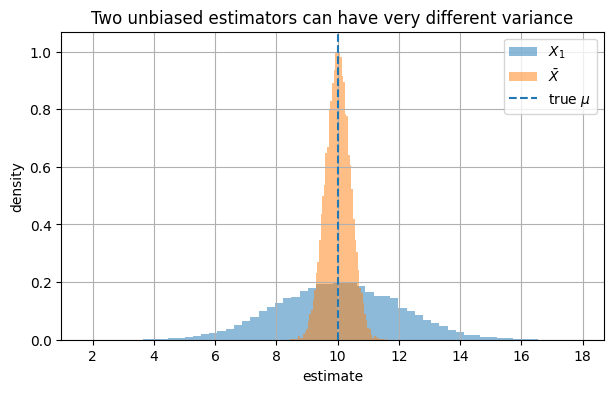

In [3]:
plt.hist(mu_hat_2, bins=60, alpha=0.5, density=True, label="$X_1$")
plt.hist(mu_hat_1, bins=60, alpha=0.5, density=True, label="$\\bar X$")
plt.axvline(mu, linestyle="--", label="true $\\mu$")
plt.title("Two unbiased estimators can have very different variance")
plt.xlabel("estimate")
plt.ylabel("density")
plt.legend()
plt.show()

## Part 2. Method of Moments

The **method of moments** matches sample moments to population moments.

For a one-parameter model, if $E_\theta[X]=m(\theta)$, the method of moments estimator solves

$$
\bar X = m(\theta).
$$

### Exercise 2: Poisson method of moments

Let $X_1,\ldots,X_n \overset{iid}{\sim}\operatorname{Poisson}(\lambda)$.

1. Derive the method of moments estimator of $\lambda$.
2. Generate data with $\lambda=4$ and estimate $\lambda$.
3. Repeat the simulation many times and estimate the bias and variance.

### Solution 2

For a Poisson random variable,

$$
E[X]=\lambda.
$$

Set the population mean equal to the sample mean:

$$
\lambda=\bar X.
$$

Therefore,

$$
\hat\lambda_{\mathrm{MOM}}=\bar X.
$$

Since $E[\bar X]=\lambda$ and $\operatorname{Var}(\bar X)=\lambda/n$,

$$
\hat\lambda_{\mathrm{MOM}}
$$

is unbiased and consistent.

In [4]:
lambda_true = 4
n = 50
x = rng.poisson(lam=lambda_true, size=n)
lambda_mom = x.mean()

print("First 15 observations:", x[:15])
print("MOM estimate lambda_hat = xbar =", lambda_mom)

First 15 observations: [4 8 0 3 3 2 5 4 5 3 2 6 7 3 4]
MOM estimate lambda_hat = xbar = 3.62


In [5]:
# Monte Carlo performance of Poisson MOM estimator
B = 20_000
samples = rng.poisson(lam=lambda_true, size=(B, n))
lambda_hats = samples.mean(axis=1)

poisson_mom_summary = summarize_estimates(lambda_hats, lambda_true)
poisson_mom_summary["theoretical variance lambda/n"] = lambda_true / n
show_table(poisson_mom_summary.to_frame("Poisson MOM"))

,Poisson MOM
mean of estimates,3.9993
true value,4.0000
bias,-0.0007
variance,0.0795
MSE,0.0795
theoretical variance lambda/n,0.0800


## Part 3. Maximum Likelihood Estimation

The **likelihood function** is the joint density or mass function viewed as a function of the unknown parameter.

For independent data,

$$
L(\theta)=\prod_{i=1}^n f(x_i|\theta).
$$

The **maximum likelihood estimator** is

$$
\hat\theta_{\mathrm{MLE}}=\arg\max_\theta L(\theta).
$$

Equivalently, we usually maximize the log-likelihood

$$
\ell(\theta)=\log L(\theta).
$$

### Exercise 3: Poisson MLE

Let $X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Poisson}(\lambda)$.

1. Derive the MLE of $\lambda$.
2. Plot the log-likelihood for one simulated data set.
3. Confirm numerically that the maximum occurs at $\bar X$.

### Solution 3

The likelihood is

$$
L(\lambda)
=\prod_{i=1}^n \frac{e^{-\lambda}\lambda^{x_i}}{x_i!}
=e^{-n\lambda}\lambda^{\sum_i x_i}\prod_{i=1}^n \frac{1}{x_i!}.
$$

The log-likelihood is

$$
\ell(\lambda)
=-n\lambda+\left(\sum_{i=1}^n x_i\right)\log\lambda-\sum_{i=1}^n\log(x_i!).
$$

Differentiate:

$$
\ell'(\lambda)
=-n+\frac{\sum_i x_i}{\lambda}.
$$

Set $\ell'(\lambda)=0$:

$$
\hat\lambda_{\mathrm{MLE}}
=\frac{1}{n}\sum_{i=1}^n X_i
=\bar X.
$$

Also,

$$
\ell''(\lambda)=-\frac{\sum_i x_i}{\lambda^2}<0,
$$

so this critical point is a maximum when $\sum_i x_i>0$.

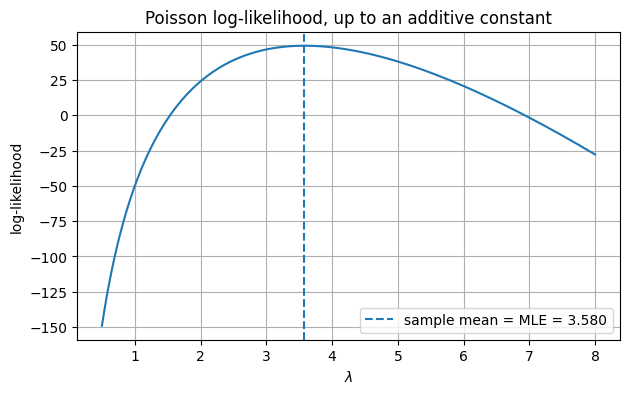

xbar = 3.58
grid maximum approximately at lambda = 3.582706766917293


In [6]:
# Plot a Poisson log-likelihood
lambda_true = 4
n = 50
x = rng.poisson(lam=lambda_true, size=n)
xbar = x.mean()
S = x.sum()

# Ignore constants that do not depend on lambda
lambda_grid = np.linspace(0.5, 8, 400)
loglik = -n * lambda_grid + S * np.log(lambda_grid)

plt.plot(lambda_grid, loglik)
plt.axvline(xbar, linestyle="--", label=f"sample mean = MLE = {xbar:.3f}")
plt.title("Poisson log-likelihood, up to an additive constant")
plt.xlabel("$\\lambda$")
plt.ylabel("log-likelihood")
plt.legend()
plt.show()

print("xbar =", xbar)
print("grid maximum approximately at lambda =", lambda_grid[np.argmax(loglik)])

## Part 4. Exponential MOM and MLE

Let $Y_1,\ldots,Y_n \overset{iid}{\sim}\operatorname{Exp}(\theta)$ with density

$$
f(y|\theta)=\frac{1}{\theta}e^{-y/\theta},\qquad y>0.
$$

Here $\theta$ is the mean/scale parameter.

### Exercise 4

1. Derive the method of moments estimator of $\theta$.
2. Derive the MLE of $\theta$.
3. Simulate the estimator and compare empirical variance with the formula $\theta^2/n$.

### Solution 4

Because $E[Y]=\theta$, the method of moments estimator is

$$
\hat\theta_{\mathrm{MOM}}=\bar Y.
$$

The likelihood is

$$
L(\theta)
=\prod_{i=1}^n \frac{1}{\theta}e^{-y_i/\theta}
=\theta^{-n}\exp\left(-\frac{\sum_i y_i}{\theta}\right).
$$

The log-likelihood is

$$
\ell(\theta)=-n\log\theta-\frac{\sum_i y_i}{\theta}.
$$

Differentiate:

$$
\ell'(\theta)=-\frac{n}{\theta}+\frac{\sum_i y_i}{\theta^2}.
$$

Set $\ell'(\theta)=0$:

$$
-n\theta+\sum_i y_i=0,
$$

so

$$
\hat\theta_{\mathrm{MLE}}=\bar Y.
$$

Because $\operatorname{Var}(Y)=\theta^2$,

$$
\operatorname{Var}(\bar Y)=\frac{\theta^2}{n}.
$$

In [7]:
theta_true = 3.0
n = 40
B = 20_000

samples = rng.exponential(scale=theta_true, size=(B, n))
theta_hats = samples.mean(axis=1)

exp_summary = summarize_estimates(theta_hats, theta_true)
exp_summary["theoretical variance theta^2/n"] = theta_true**2 / n
show_table(exp_summary.to_frame("Exponential mean estimator"))

,Exponential mean estimator
mean of estimates,3.0022
true value,3.0000
bias,0.0022
variance,0.2268
MSE,0.2268
theoretical variance theta^2/n,0.2250


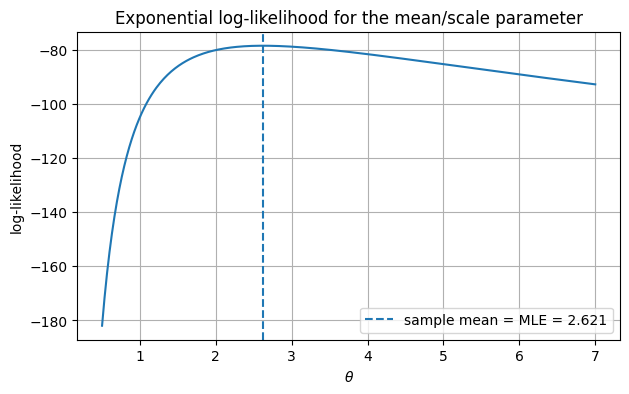

In [8]:
# One data set and its log-likelihood
sample = rng.exponential(scale=theta_true, size=n)
ybar = sample.mean()
S = sample.sum()

theta_grid = np.linspace(0.5, 7, 400)
loglik = -n*np.log(theta_grid) - S/theta_grid

plt.plot(theta_grid, loglik)
plt.axvline(ybar, linestyle="--", label=f"sample mean = MLE = {ybar:.3f}")
plt.title("Exponential log-likelihood for the mean/scale parameter")
plt.xlabel("$\\theta$")
plt.ylabel("log-likelihood")
plt.legend()
plt.show()

## Part 5. Bayesian point estimation with conjugate priors

Under squared error loss, the Bayes estimator is the posterior mean:

$$
\hat\theta_{\mathrm{Bayes}}=E[\theta|\text{data}].
$$

### Exercise 5A: Poisson-Gamma model

Let

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Poisson}(\lambda),
$$

and use the Gamma prior with shape $a$ and rate $b$:

$$
\lambda\sim\operatorname{Gamma}(a,b).
$$

1. Derive the posterior distribution.
2. Find the Bayes estimator under squared error loss.
3. Compare the MLE and Bayes estimator for a small sample.

### Solution 5A

The likelihood, ignoring constants not involving $\lambda$, is

$$
L(\lambda)\propto \lambda^{\sum_i x_i}e^{-n\lambda}.
$$

The prior density is

$$
\pi(\lambda)\propto \lambda^{a-1}e^{-b\lambda}.
$$

Therefore, the posterior is

$$
\pi(\lambda|x)
\propto
\lambda^{a+\sum_i x_i-1}e^{-(b+n)\lambda}.
$$

Thus

$$
\lambda|x_1,\ldots,x_n\sim \operatorname{Gamma}\left(a+\sum_{i=1}^n x_i,\ b+n\right).
$$

The Bayes estimator under squared error loss is the posterior mean:

$$
\hat\lambda_{\mathrm{Bayes}}
=\frac{a+\sum_i x_i}{b+n}.
$$

data: [7 5 6 2 6 4 1 2]
sum S: 33
MLE xbar: 4.125
posterior Gamma shape: 35
posterior Gamma rate: 9
Bayes estimator/posterior mean: 3.888888888888889


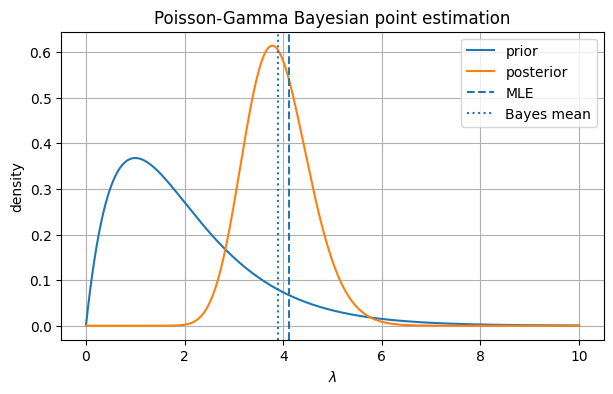

In [9]:
# Small-sample Poisson Bayes example
lambda_true = 4
n = 8
x = rng.poisson(lambda_true, size=n)
S = x.sum()

# Prior Gamma(a,b), rate parameter b
prior_a = 2
prior_b = 1
post_a = prior_a + S
post_b = prior_b + n

lambda_mle = x.mean()
lambda_bayes = post_a / post_b

print("data:", x)
print("sum S:", S)
print("MLE xbar:", lambda_mle)
print("posterior Gamma shape:", post_a)
print("posterior Gamma rate:", post_b)
print("Bayes estimator/posterior mean:", lambda_bayes)

lam_grid = np.linspace(0, 10, 500)
prior_pdf = st.gamma(a=prior_a, scale=1/prior_b).pdf(lam_grid)
post_pdf = st.gamma(a=post_a, scale=1/post_b).pdf(lam_grid)

plt.plot(lam_grid, prior_pdf, label="prior")
plt.plot(lam_grid, post_pdf, label="posterior")
plt.axvline(lambda_mle, linestyle="--", label="MLE")
plt.axvline(lambda_bayes, linestyle=":", label="Bayes mean")
plt.title("Poisson-Gamma Bayesian point estimation")
plt.xlabel("$\\lambda$")
plt.ylabel("density")
plt.legend()
plt.show()

### Exercise 5B: Exponential-Inverse-Gamma model

Let

$$
Y_1,\ldots,Y_n\overset{iid}{\sim}\operatorname{Exp}(\theta),
$$

where $\theta$ is the mean/scale parameter. Use the Inverse-Gamma prior

$$
\theta\sim\operatorname{Inv\text{-}Gamma}(a,b),
$$

with density proportional to

$$
\theta^{-(a+1)}e^{-b/\theta},\qquad \theta>0.
$$

1. Derive the posterior distribution.
2. Find the Bayes estimator under squared error loss.
3. Compare the MLE and Bayes estimator.

### Solution 5B

The likelihood is

$$
L(\theta)
=\theta^{-n}\exp\left(-\frac{\sum_i y_i}{\theta}\right).
$$

The prior is

$$
\pi(\theta)\propto \theta^{-(a+1)}e^{-b/\theta}.
$$

Therefore,

$$
\pi(\theta|y)
\propto
\theta^{-(a+n+1)}
\exp\left(-\frac{b+\sum_i y_i}{\theta}\right).
$$

Thus

$$
\theta|y_1,\ldots,y_n
\sim
\operatorname{Inv\text{-}Gamma}\left(a+n,\ b+\sum_{i=1}^n y_i\right).
$$

The posterior mean exists when $a+n>1$ and equals

$$
\hat\theta_{\mathrm{Bayes}}
=E[\theta|y]
=\frac{b+\sum_i y_i}{a+n-1}.
$$

data: [0.703 1.903 3.547 5.548 1.038 0.555 0.831 1.016]
sum S: 15.140486731061145
MLE ybar: 1.8925608413826431
posterior Inv-Gamma shape: 11
posterior Inv-Gamma scale: 21.140486731061145
Bayes estimator/posterior mean: 2.1140486731061143


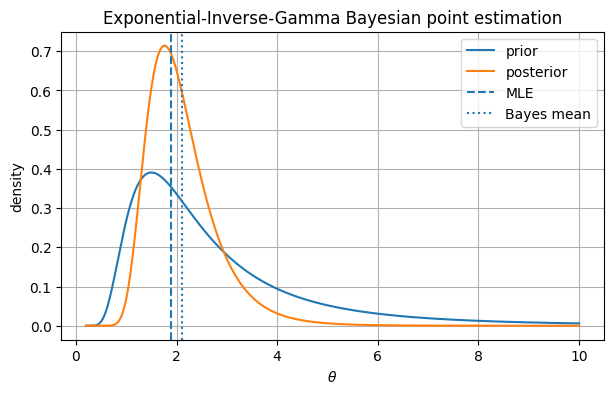

In [10]:
# Small-sample Exponential Bayes example
true_theta = 3.0
n = 8
y = rng.exponential(scale=true_theta, size=n)
S = y.sum()

prior_a = 3
prior_b = 6
post_a = prior_a + n
post_b = prior_b + S

theta_mle = y.mean()
theta_bayes = post_b / (post_a - 1)

print("data:", np.round(y, 3))
print("sum S:", S)
print("MLE ybar:", theta_mle)
print("posterior Inv-Gamma shape:", post_a)
print("posterior Inv-Gamma scale:", post_b)
print("Bayes estimator/posterior mean:", theta_bayes)

theta_grid = np.linspace(0.2, 10, 500)
prior_pdf = st.invgamma(a=prior_a, scale=prior_b).pdf(theta_grid)
post_pdf = st.invgamma(a=post_a, scale=post_b).pdf(theta_grid)

plt.plot(theta_grid, prior_pdf, label="prior")
plt.plot(theta_grid, post_pdf, label="posterior")
plt.axvline(theta_mle, linestyle="--", label="MLE")
plt.axvline(theta_bayes, linestyle=":", label="Bayes mean")
plt.title("Exponential-Inverse-Gamma Bayesian point estimation")
plt.xlabel("$\\theta$")
plt.ylabel("density")
plt.legend()
plt.show()

## Part 6. Consistency

An estimator $\hat\theta_n$ is **consistent** for $\theta$ if

$$
\hat\theta_n \overset{P}{\longrightarrow} \theta.
$$

For many sample-mean estimators, consistency follows from the Law of Large Numbers.

### Exercise 6

For $X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Poisson}(\lambda)$, show that

$$
\hat\lambda_n=\bar X_n
$$

is consistent. Then verify this by simulation.

### Solution 6

Because $E[X_i]=\lambda$ and $\operatorname{Var}(X_i)=\lambda<\infty$, the Law of Large Numbers gives

$$
\bar X_n \overset{P}{\longrightarrow} E[X_i]=\lambda.
$$

Therefore $\hat\lambda_n=\bar X_n$ is consistent.

The simulation below shows the sampling distribution of $\bar X_n$ becoming more concentrated near $\lambda$ as $n$ increases.

In [11]:
lambda_true = 5
B = 10_000
sample_sizes = [5, 10, 30, 100, 500]

rows = []
all_estimates = {}
for n in sample_sizes:
    samples = rng.poisson(lam=lambda_true, size=(B, n))
    estimates = samples.mean(axis=1)
    all_estimates[n] = estimates
    rows.append({
        "n": n,
        "mean estimate": estimates.mean(),
        "variance estimate": estimates.var(ddof=1),
        "P(|hat-lambda| > 0.5)": np.mean(np.abs(estimates - lambda_true) > 0.5),
    })

consistency_df = pd.DataFrame(rows)
show_table(consistency_df)

,n,mean estimate,variance estimate,P(|hat-lambda| > 0.5)
0,5,4.9974,0.9957,0.6175
1,10,4.9966,0.4962,0.4330
2,30,4.9992,0.1648,0.2025
3,100,4.9969,0.0502,0.0266
4,500,5.0005,0.0099,0.0000


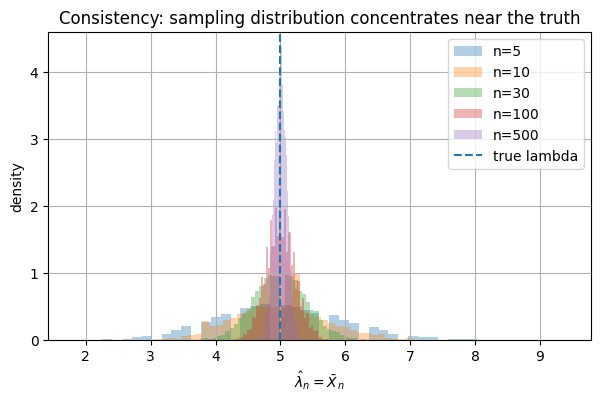

In [12]:
for n in sample_sizes:
    plt.hist(all_estimates[n], bins=50, density=True, alpha=0.35, label=f"n={n}")
plt.axvline(lambda_true, linestyle="--", label="true lambda")
plt.title("Consistency: sampling distribution concentrates near the truth")
plt.xlabel("$\\hat\\lambda_n=\\bar X_n$")
plt.ylabel("density")
plt.legend()
plt.show()

## Part 7. Bias correction: sample variance

Let $X_1,\ldots,X_n$ be iid with variance $\sigma^2$. Define

$$
S_n^2=\frac{1}{n}\sum_{i=1}^n (X_i-\bar X)^2,
$$

and

$$
S_{n-1}^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2.
$$

### Exercise 7

1. Use simulation to show that $S_n^2$ is biased downward for $\sigma^2$.
2. Use simulation to show that $S_{n-1}^2$ is approximately unbiased.

### Solution 7

A standard identity is

$$
E\left[\sum_{i=1}^n (X_i-\bar X)^2\right]=(n-1)\sigma^2.
$$

Therefore,

$$
E[S_n^2]=E\left[\frac{1}{n}\sum_{i=1}^n (X_i-\bar X)^2\right]
=\frac{n-1}{n}\sigma^2,
$$

so $S_n^2$ is biased downward.

But

$$
E[S_{n-1}^2]=E\left[\frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2\right]
=\sigma^2,
$$

so $S_{n-1}^2$ is unbiased.

In [13]:
mu = 0
sigma = 2
sigma2 = sigma**2
n = 10
B = 50_000

samples = rng.normal(mu, sigma, size=(B, n))
biased_var = samples.var(axis=1, ddof=0)      # divide by n
unbiased_var = samples.var(axis=1, ddof=1)    # divide by n-1

variance_bias_df = pd.DataFrame({
    "estimator": ["divide by n", "divide by n-1"],
    "average estimate": [biased_var.mean(), unbiased_var.mean()],
    "true sigma^2": [sigma2, sigma2],
    "theoretical expectation": [(n-1)/n*sigma2, sigma2],
})

show_table(variance_bias_df)

,estimator,average estimate,true sigma^2,theoretical expectation
0,divide by n,3.5950,4,3.6
1,divide by n-1,3.9945,4,4.0


## Part 8. Fisher information and the Cramér--Rao lower bound

For an unbiased estimator $T$ of $\theta$, the Cramér--Rao inequality says

$$
\operatorname{Var}(T)\geq \frac{1}{I_n(\theta)},
$$

where $I_n(\theta)$ is the Fisher information in the full sample.

For iid data,

$$
I_n(\theta)=nI_1(\theta).
$$

### Exercise 8A: Poisson CRLB

Let $X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Poisson}(\lambda)$.

1. Compute the Fisher information for one observation.
2. Find the CRLB for unbiased estimators of $\lambda$.
3. Show that $\hat\lambda=\bar X$ achieves the CRLB.

### Solution 8A

For one observation,

$$
\log f(X|\lambda)=-\lambda+X\log\lambda-\log(X!).
$$

The score is

$$
\frac{\partial}{\partial\lambda}\log f(X|\lambda)
=-1+\frac{X}{\lambda}.
$$

The Fisher information is

$$
I_1(\lambda)=E\left[\left(-1+\frac{X}{\lambda}\right)^2\right].
$$

Because $E[X]=\lambda$ and $\operatorname{Var}(X)=\lambda$,

$$
I_1(\lambda)=\frac{1}{\lambda}.
$$

Thus

$$
I_n(\lambda)=\frac{n}{\lambda},
$$

and the CRLB is

$$
\operatorname{Var}(T)\geq \frac{\lambda}{n}.
$$

For $\hat\lambda=\bar X$,

$$
\operatorname{Var}(\bar X)=\frac{\lambda}{n}.
$$

So $\bar X$ achieves the CRLB and is efficient among unbiased estimators.

In [14]:
# Verify Poisson CRLB by simulation
lambda_true = 6
n = 30
B = 30_000
samples = rng.poisson(lambda_true, size=(B, n))
lambda_hats = samples.mean(axis=1)

pd.DataFrame({
    "quantity": ["empirical Var(xbar)", "CRLB lambda/n"],
    "value": [lambda_hats.var(ddof=1), lambda_true/n]
}).round(5)

,quantity,value
0,empirical Var(xbar),0.19915
1,CRLB lambda/n,0.20000


### Exercise 8B: Exponential CRLB

Let $Y_1,\ldots,Y_n\overset{iid}{\sim}\operatorname{Exp}(\theta)$ with mean/scale parameter $\theta$.

1. Compute the Fisher information for one observation.
2. Find the CRLB for unbiased estimators of $\theta$.
3. Show that $\hat\theta=\bar Y$ achieves the CRLB.

### Solution 8B

For one observation,

$$
\log f(Y|\theta)=-\log\theta-\frac{Y}{\theta}.
$$

The score is

$$
\frac{\partial}{\partial\theta}\log f(Y|\theta)
=-\frac{1}{\theta}+\frac{Y}{\theta^2}.
$$

The Fisher information is

$$
I_1(\theta)=E\left[\left(-\frac{1}{\theta}+\frac{Y}{\theta^2}\right)^2\right]
=\frac{1}{\theta^2}.
$$

Thus

$$
I_n(\theta)=\frac{n}{\theta^2},
$$

and the CRLB is

$$
\operatorname{Var}(T)\geq \frac{\theta^2}{n}.
$$

For $\hat\theta=\bar Y$,

$$
\operatorname{Var}(\bar Y)=\frac{\theta^2}{n}.
$$

So $\bar Y$ achieves the CRLB and is efficient among unbiased estimators.

In [15]:
# Verify Exponential CRLB by simulation
theta_true = 3
n = 30
B = 30_000
samples = rng.exponential(scale=theta_true, size=(B, n))
theta_hats = samples.mean(axis=1)

pd.DataFrame({
    "quantity": ["empirical Var(ybar)", "CRLB theta^2/n"],
    "value": [theta_hats.var(ddof=1), theta_true**2/n]
}).round(5)

,quantity,value
0,empirical Var(ybar),0.30204
1,CRLB theta^2/n,0.30000


## Part 9. Numerical MLE by optimization

In real applications, the MLE may not have a closed form. We can still find it by numerical optimization.

### Exercise 9: Gamma distribution with known shape

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Gamma}(\alpha,\beta),
$$

where $\alpha$ is known and $\beta$ is the unknown **rate** parameter. The density is

$$
f(x|\beta)=\frac{\beta^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x},\qquad x>0.
$$

1. Derive the MLE of $\beta$.
2. Find the MLE numerically using `scipy.optimize`.

### Solution 9

Ignoring constants not involving $\beta$,

$$
\ell(\beta)=n\alpha\log\beta-\beta\sum_{i=1}^n x_i + C.
$$

Differentiate:

$$
\ell'(\beta)=\frac{n\alpha}{\beta}-\sum_{i=1}^n x_i.
$$

Set equal to zero:

$$
\hat\beta=\frac{n\alpha}{\sum_i x_i}=\frac{\alpha}{\bar X}.
$$

The numerical optimizer should return the same value.

In [16]:
alpha_known = 2.5
beta_true = 1.2
n = 100
x = rng.gamma(shape=alpha_known, scale=1/beta_true, size=n)  # numpy uses scale = 1/rate

beta_closed_form = alpha_known / x.mean()

# Negative log-likelihood up to a constant
def neg_loglik(beta):
    if beta <= 0:
        return np.inf
    return -(n * alpha_known * np.log(beta) - beta * x.sum())

result = minimize_scalar(neg_loglik, bounds=(0.01, 10), method="bounded")
beta_numeric = result.x

print("Closed-form MLE:", beta_closed_form)
print("Numerical MLE:", beta_numeric)
print("True beta:", beta_true)

Closed-form MLE: 1.2345072480169148
Numerical MLE: 1.234507486939126
True beta: 1.2


## Part 10. Lab report questions

Write a short answer to each question.

1. In the Poisson model, why are the MOM estimator and MLE the same?
2. In the Exponential mean model, why are the MOM estimator and MLE the same?
3. What does it mean for an estimator to be unbiased?
4. What does it mean for an estimator to be consistent?
5. What does it mean for an unbiased estimator to achieve the CRLB?
6. In the Poisson-Gamma model, how does the prior affect the Bayes estimator when $n$ is small?
7. Why does the prior have less effect when $n$ is large?

## Solutions to lab report questions

1. For the Poisson model, $E[X]=\lambda$, so MOM gives $\hat\lambda=\bar X$. The likelihood equation also gives $\hat\lambda=\bar X$.
2. For the Exponential model with mean parameter $\theta$, $E[Y]=\theta$, so MOM gives $\hat\theta=\bar Y$. The likelihood equation also gives $\hat\theta=\bar Y$.
3. An estimator $\hat\theta$ is unbiased if $E[\hat\theta]=\theta$ for all parameter values in the model.
4. An estimator $\hat\theta_n$ is consistent if $\hat\theta_n\to\theta$ in probability as $n\to\infty$.
5. Achieving the CRLB means the unbiased estimator has variance equal to the theoretical minimum $1/I_n(\theta)$. Such an estimator is efficient among unbiased estimators.
6. When $n$ is small, the posterior mean is a weighted compromise between the prior information and the data. For Poisson-Gamma, $\hat\lambda_{\mathrm{Bayes}}=(a+S)/(b+n)$, so $a$ and $b$ can noticeably shift the estimate.
7. When $n$ is large, the data terms $S$ and $n$ dominate the fixed prior hyperparameters. Therefore the Bayes estimator becomes close to the MLE.

## Summary

In Sections 12 and 13, the key computational and theoretical lessons are:

- An estimator is itself a random variable.
- Bias, variance, and MSE measure different aspects of estimator quality.
- MOM matches theoretical moments to sample moments.
- MLE maximizes the likelihood or log-likelihood.
- Bayesian point estimation under squared error loss uses the posterior mean.
- Consistency is about large-sample convergence to the true parameter.
- The Cramér--Rao lower bound gives a benchmark for the variance of unbiased estimators.
- For Poisson and Exponential mean models, the sample mean is unbiased, consistent, and efficient.